## Exploratory Data Analysis
### We retrain our dataset using CatBoost Model that was wrangled in previous section `101-DataWrangling-MPOWER.ipynb` notebook, to compute SHAP plots to identify appropriate policy levers

1. Plot generic SHAP plot
2. Plat SHAP across age groups to crucial age-based levers

(1) Plot generic SHAP plot

In [43]:
#import cleaned_Data_splits_with_NaN.pkl file
import pickle
with open('../data/modeling/part2/cleaned_data_splits_with_NaN.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_train_with_NaN = data_splits['X_train_with_NaN']
X_test_with_NaN = data_splits['X_test_with_NaN']
y_train_clean = data_splits['y_train_clean']
y_test_clean = data_splits['y_test_clean']
X_combined_with_NaN = data_splits['X_combined_with_NaN']
y_combined = data_splits['y_combined']


In [44]:
#import nominal and ordinal features for future use
import pickle
with open('../data/modeling/part2/nominal_ordinal_features.pkl', 'rb') as f:
    features = pickle.load(f)
nominal_features = features['nominal_features']
ordinal_features = features['ordinal_features']


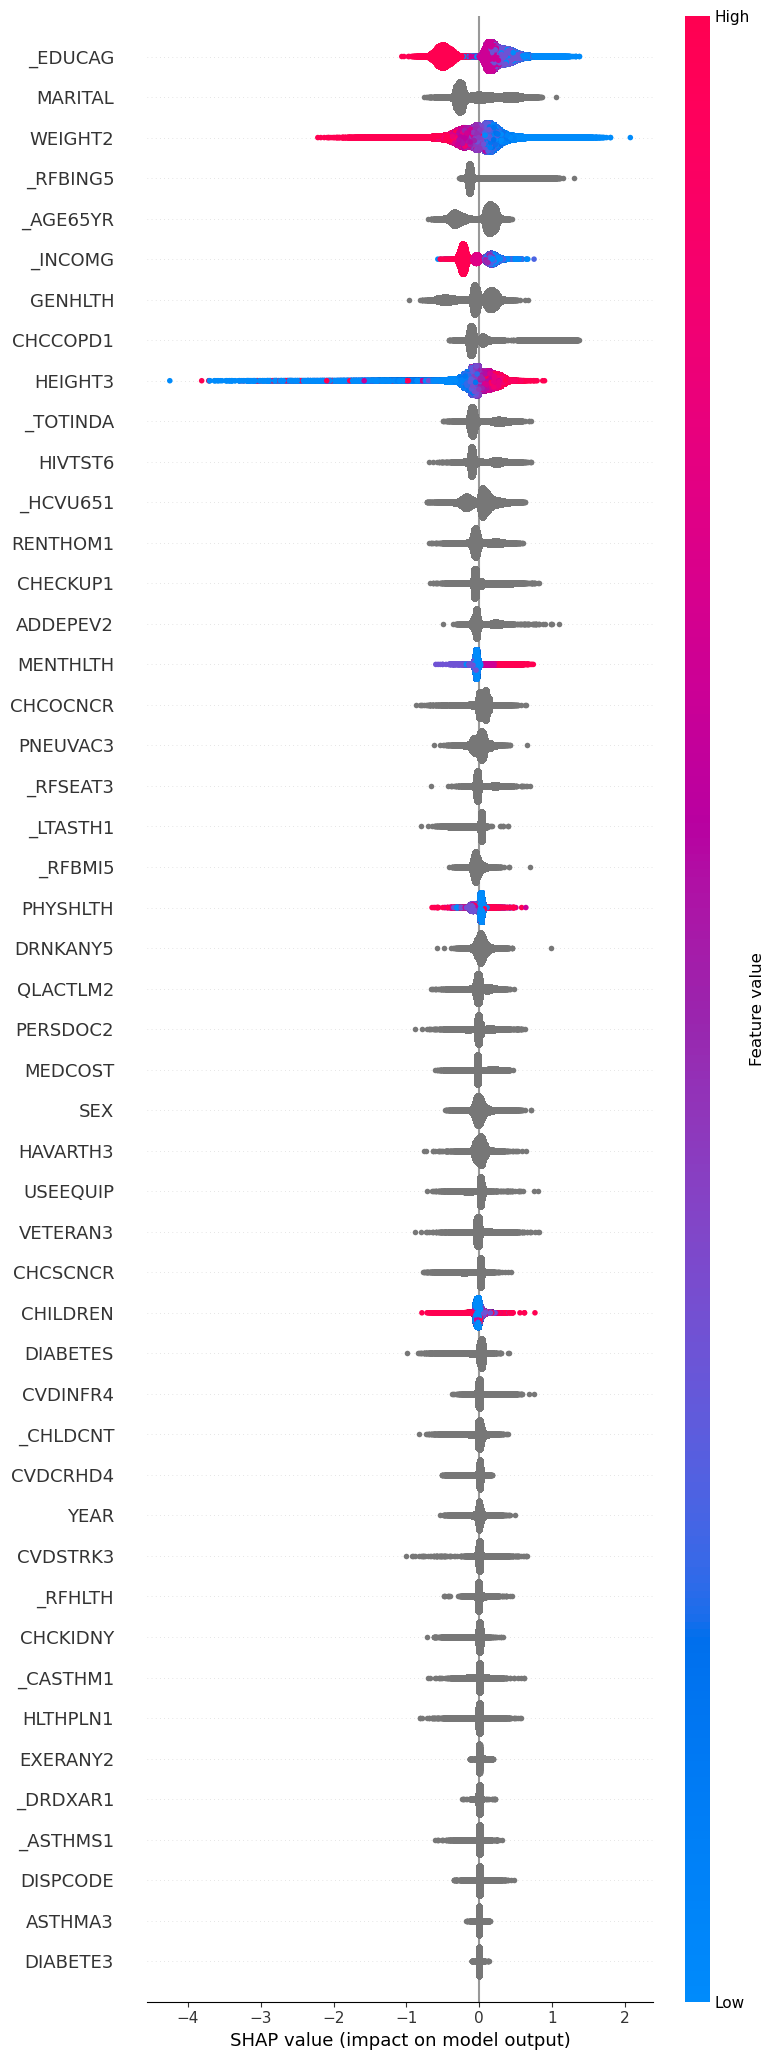

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2892505099.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


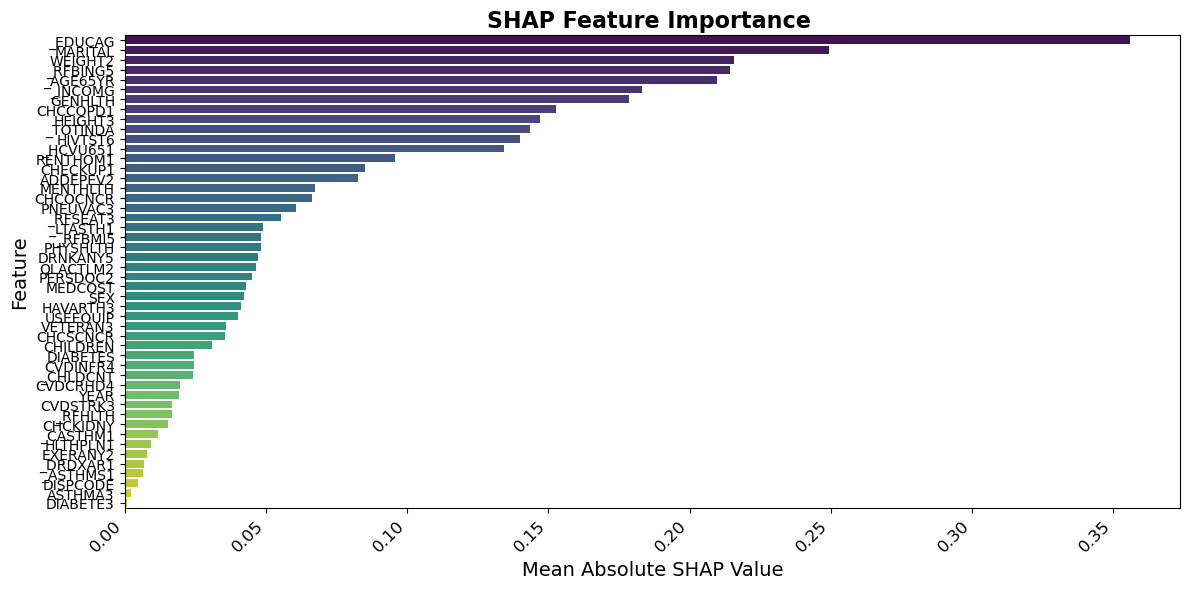

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

from catboost import Pool
import shap
import numpy as np

# Ensure indices are aligned
X_combined_with_NaN.reset_index(drop=True, inplace=True)
y_combined.reset_index(drop=True, inplace=True) 
# Create a DataFrame for easier handling
df = X_combined_with_NaN.copy()

# Features to use (excluding target and _AGE_G)
feature_cols = [col for col in df.columns if col not in ['_RFSMOK3', '_AGE_G']]  # replace 'target' as needed

# Ordinal features → Int64 (nullable integer type)
for col in ordinal_features:
    if col in X_combined_with_NaN.columns:
        X_combined_with_NaN[col] = X_combined_with_NaN[col].astype('Int64')

# Nominal features → string
for col in nominal_features:
    X_combined_with_NaN[col] = (
        X_combined_with_NaN[col].astype(str).replace("nan", "Unknown")
    )


# Train CatBoost model
model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
cat_features=nominal_features)
# Wrap your data in a Pool
train_pool = Pool(data=X_combined_with_NaN, label=y_combined, cat_features=nominal_features)
# Training
model.fit(train_pool)
# Feature importance
shap_values = model.get_feature_importance(train_pool,type='ShapValues')

#agregate by HBM constructs by SHAP values
# The first column is the expected value, so we take the mean absolute SHAP value
shap_values_no_base = shap_values[:, :-1]
# Summary plot
#shap.summary_plot(shap_values_no_base, X_combined_with_NaN, feature_names=X_combined_with_NaN.columns)

expected_value = shap_values[0, -1]

shap.summary_plot(
    shap_values_no_base,              # shape = (n_samples, n_features)
    X_combined_with_NaN,              # shape = (n_samples, n_features)
    feature_names=X_combined_with_NaN.columns,
    max_display=len(X_combined_with_NaN.columns)
)

shap_values_mean = np.abs(shap_values_no_base).mean(axis=0)
# Create a Series for easier handling

feature_importance_series = pd.Series(shap_values_mean, index=feature_cols)
# feature_importance_series = pd.Series(importances, index=feature_cols)
# feature_importance_series = pd.Series(importances, index=feature_cols)
# feature_importance_series = pd.Series(importances, index=feature_cols)

#plot the shap values for each age group
plt.figure(figsize=(12, 6))  # wider figure helps spacing
shap_values_sorted = feature_importance_series.sort_values(ascending=False)

sns.barplot(
    x=shap_values_sorted.values, 
    y=shap_values_sorted.index, 
    palette="viridis"
)

plt.title(f'SHAP Feature Importance ', fontsize=16, weight='bold')
plt.xlabel('Mean Absolute SHAP Value', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Fix overlapping x-axis labels
plt.xticks(rotation=45, ha='right')   # tilt labels
plt.tick_params(axis='x', labelsize=12)  # bigger, readable ticks

plt.tight_layout()
plt.show()


#save the model for each age group
model.save_model(f'../models/part2/catboost_model_for_SHAP_plots.cbm')


(2) Plot age-based SHAP plot

In [48]:
#import ../data/processed/002-eda_final_for_report.pkl (this is to fetch rows for specific age groups) for plotting age group specific SHAP plots
with open('../data/processed/002-eda_final_for_report.pkl', 'rb') as f:
    df_for_report = pickle.load(f)

In [50]:
len(df_for_report)

2379992

In [51]:
df_for_report.columns

Index(['_STATE', 'DISPCODE', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'HLTHPLN1',
       'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3',
       'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2',
       'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3',
       'CHILDREN', 'WEIGHT2', 'HEIGHT3', 'QLACTLM2', 'USEEQUIP', 'SMOKE100',
       'USENOW3', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', 'QSTVER', '_RFHLTH',
       '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_AGE65YR',
       '_AGE_G', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_SMOKER3',
       '_RFSMOK3', 'DRNKANY5', 'DROCDY3_', '_RFBING5', '_TOTINDA', '_RFSEAT3',
       'YEAR', 'MENTHLTH_TEMP_1', 'MENTHLTH_TEMP_2', 'PHYSHLTH_TEMP_1',
       'PHYSHLTH_TEMP_2'],
      dtype='object')

119912


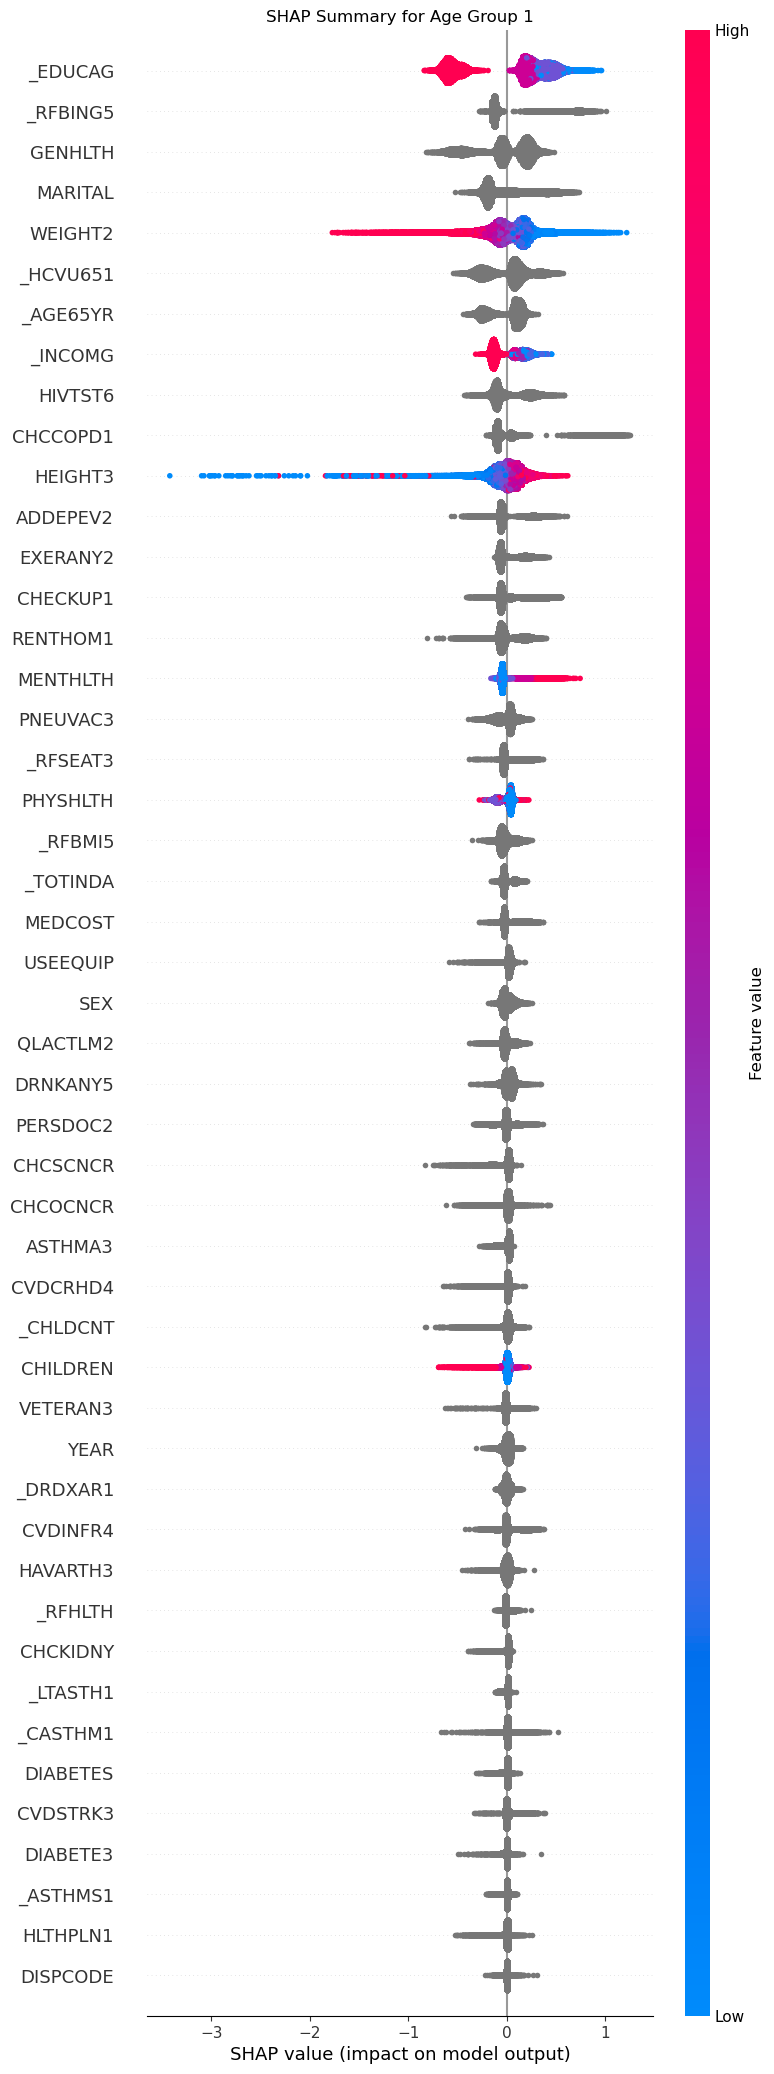

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2096381755.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


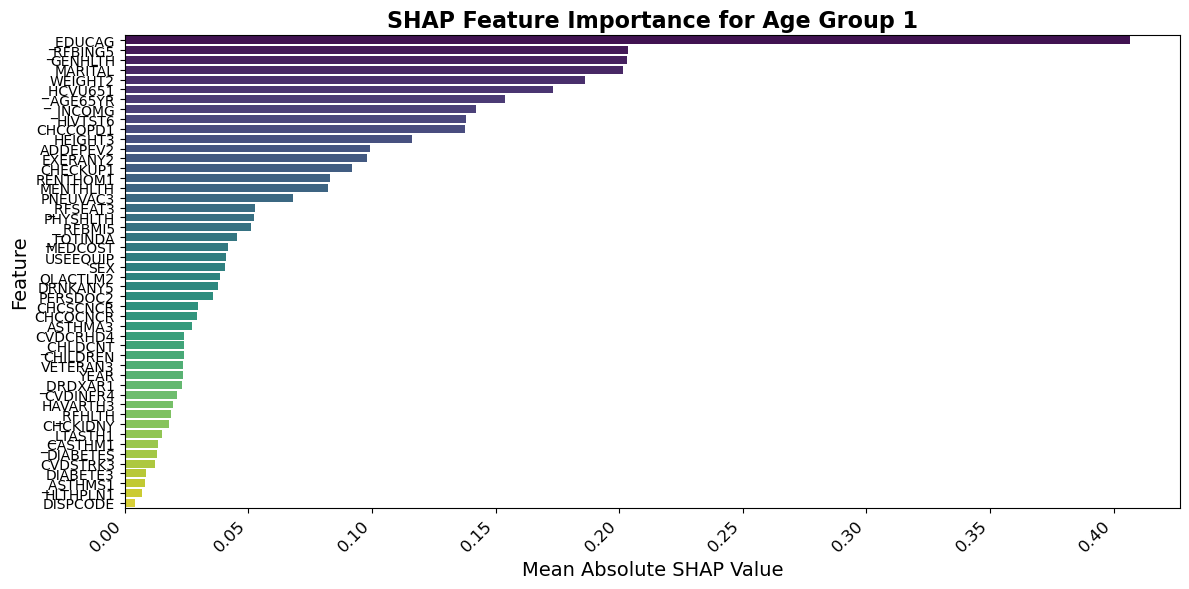

226275


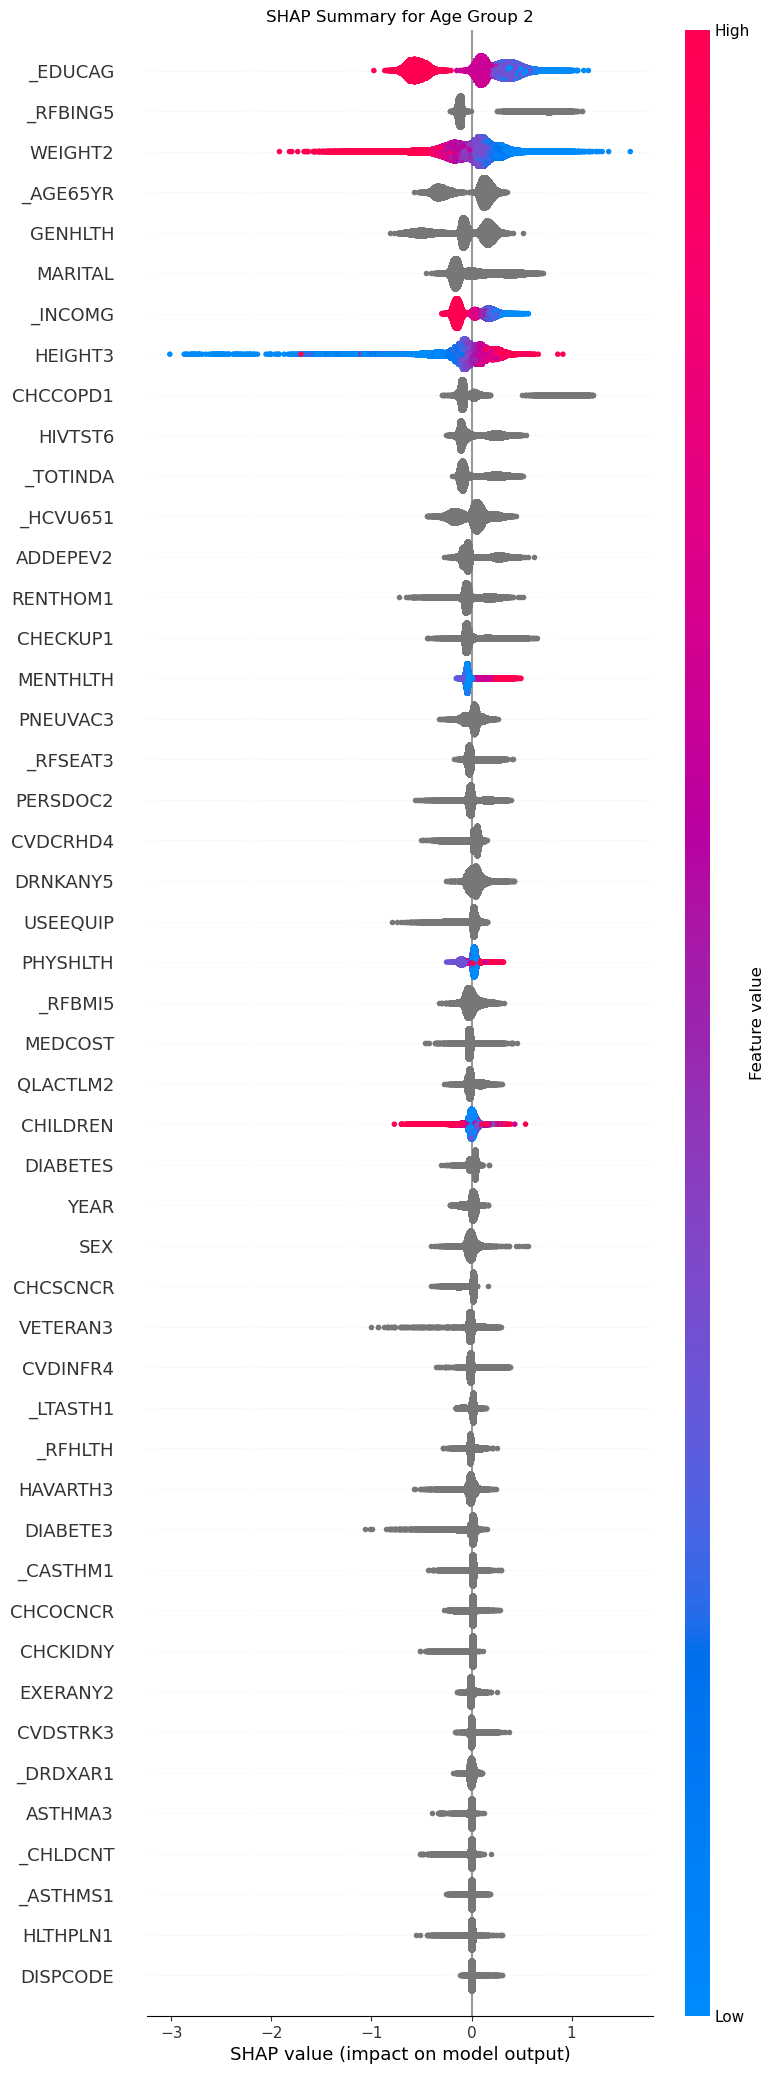

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2096381755.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


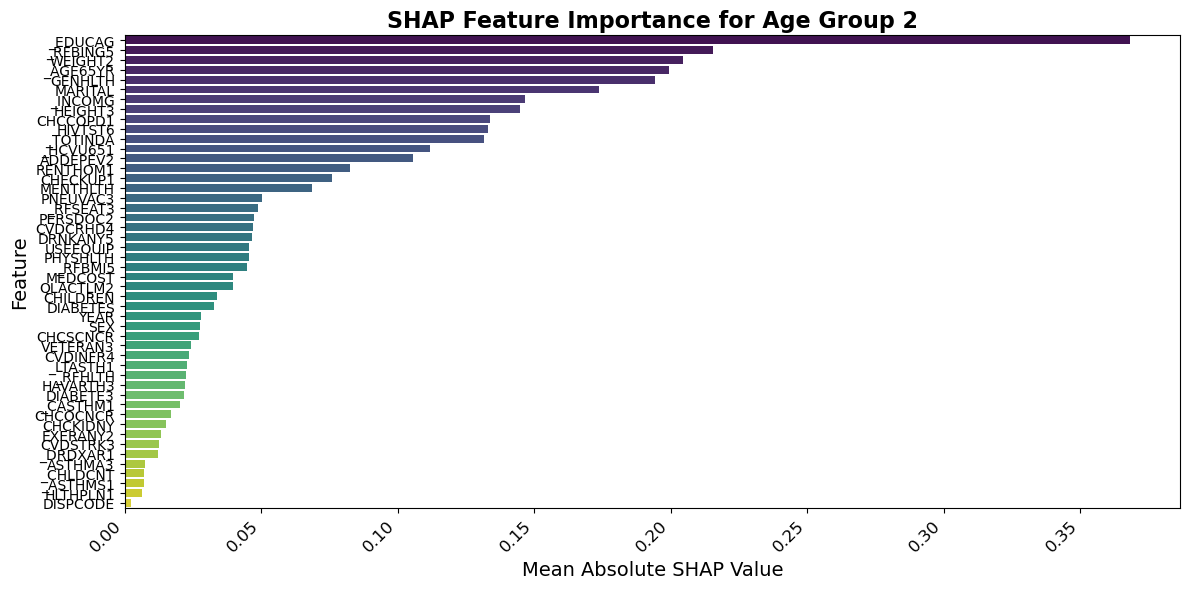

281908


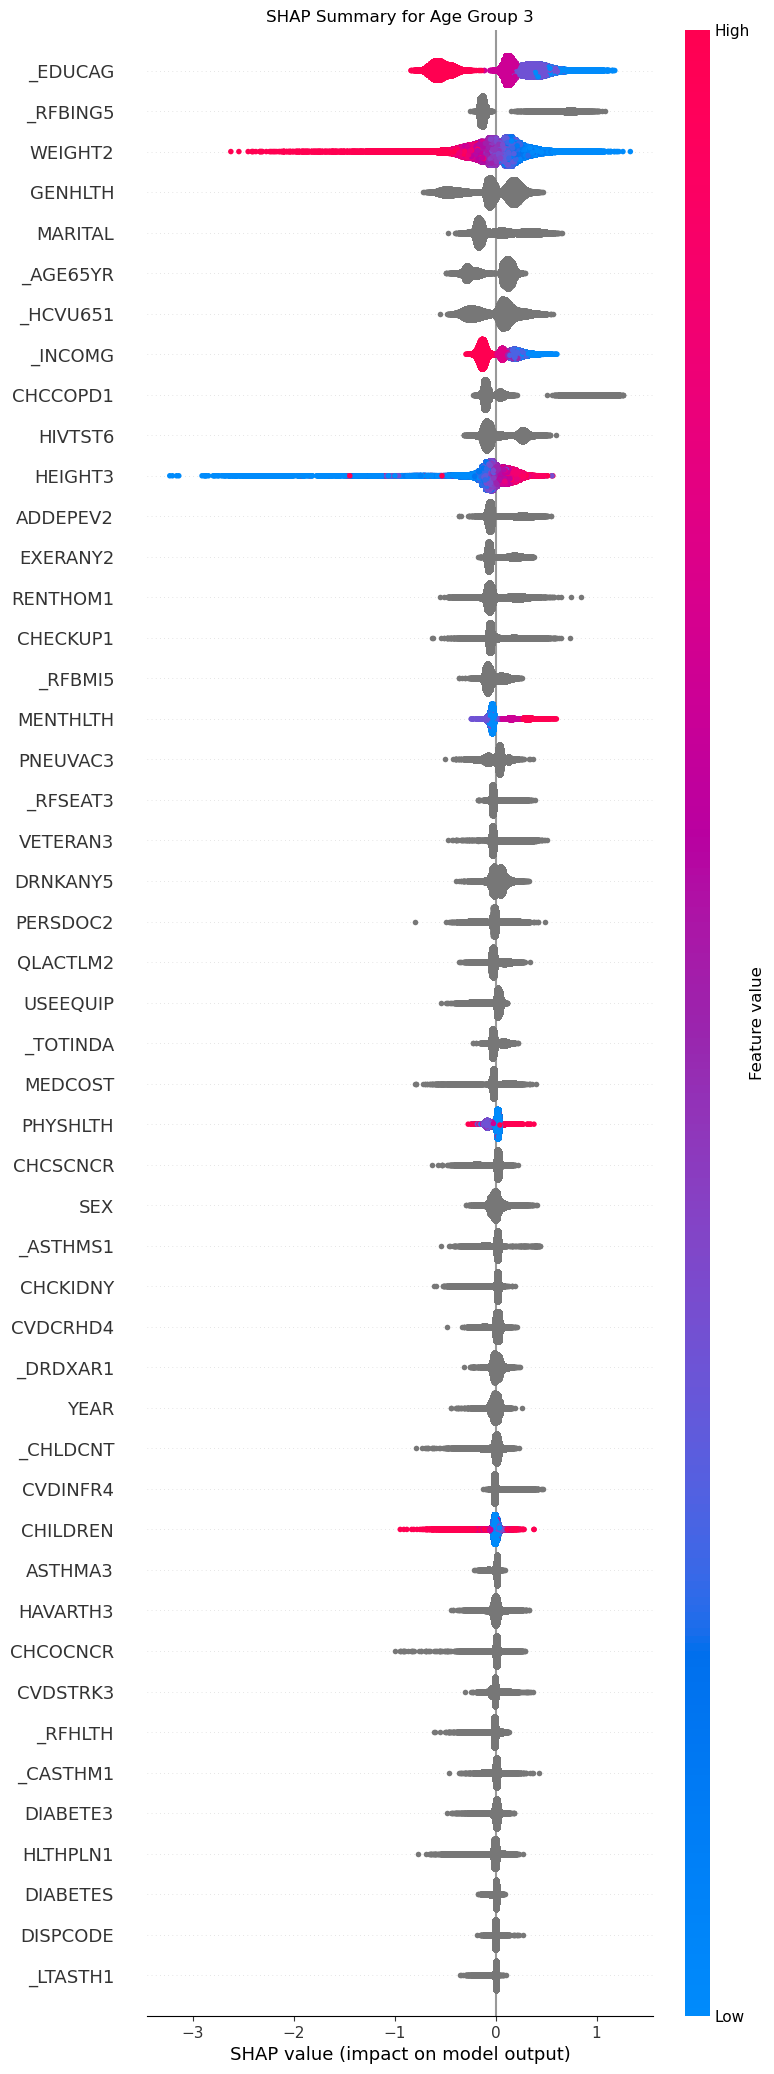

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2096381755.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


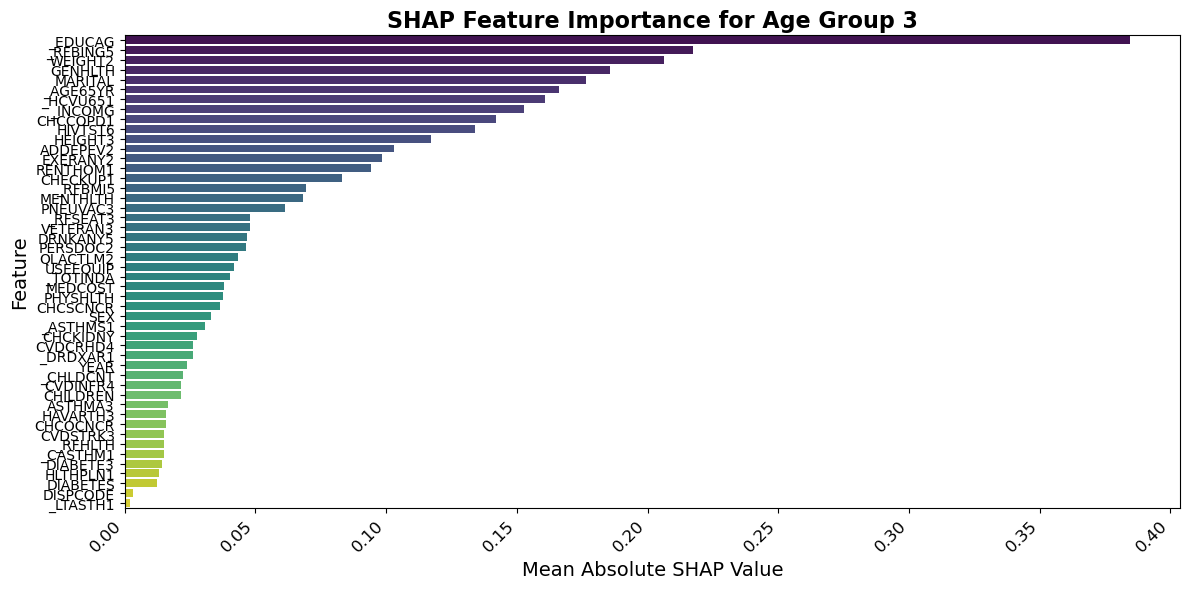

397115


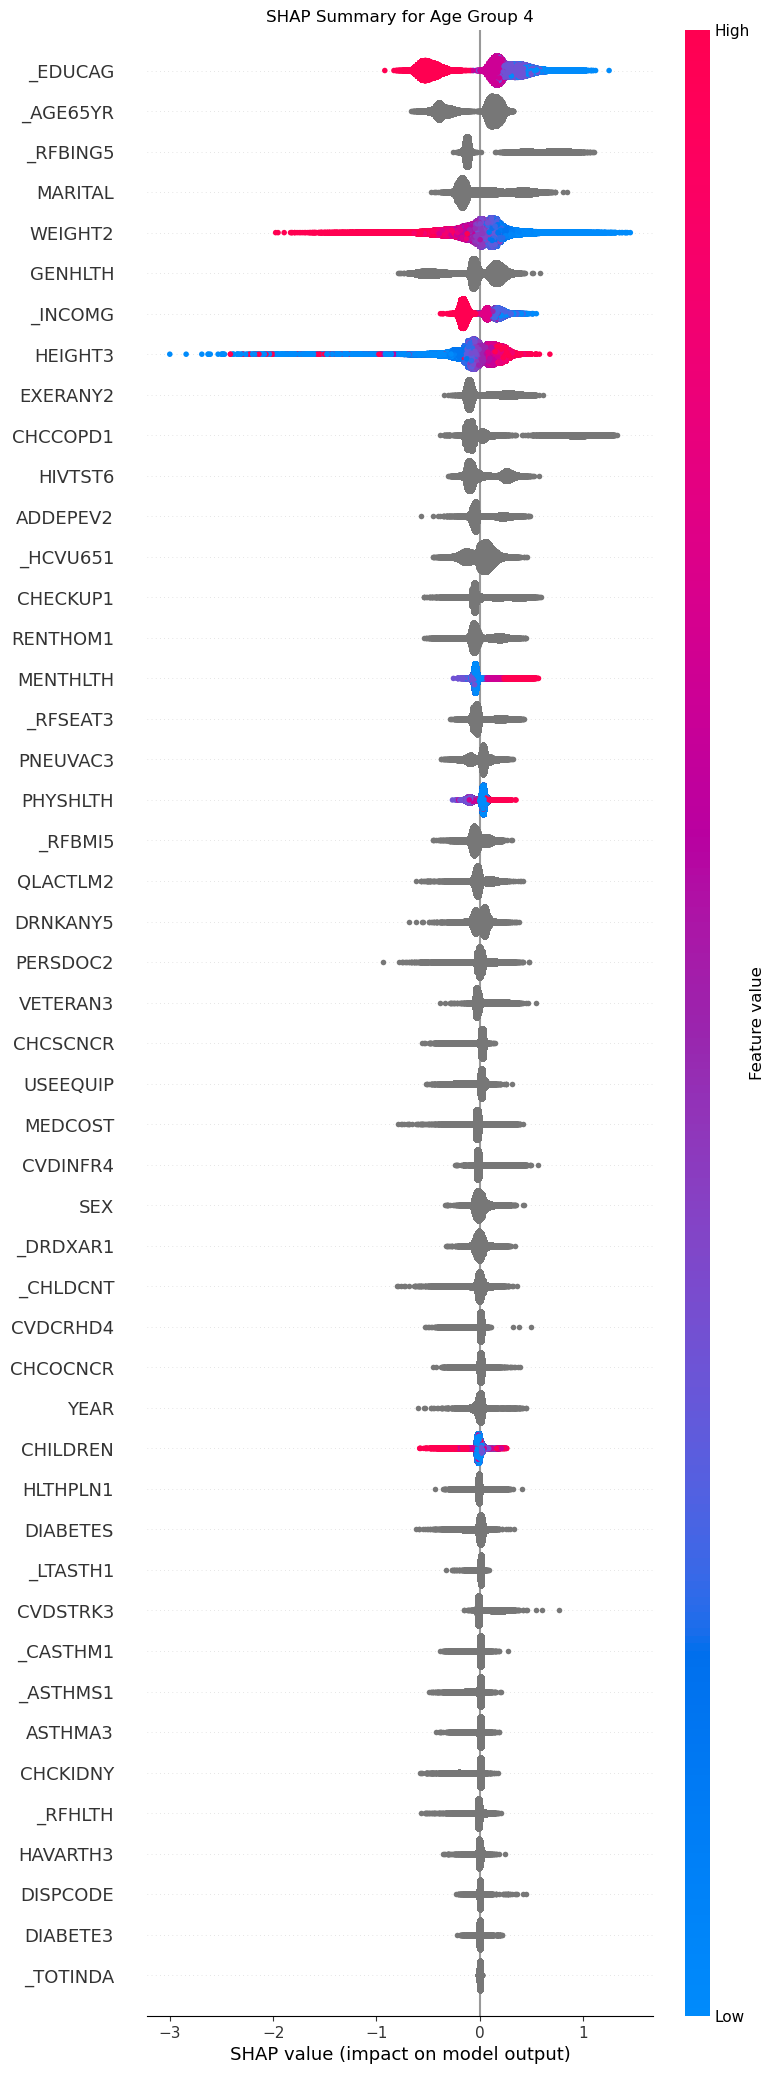

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2096381755.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


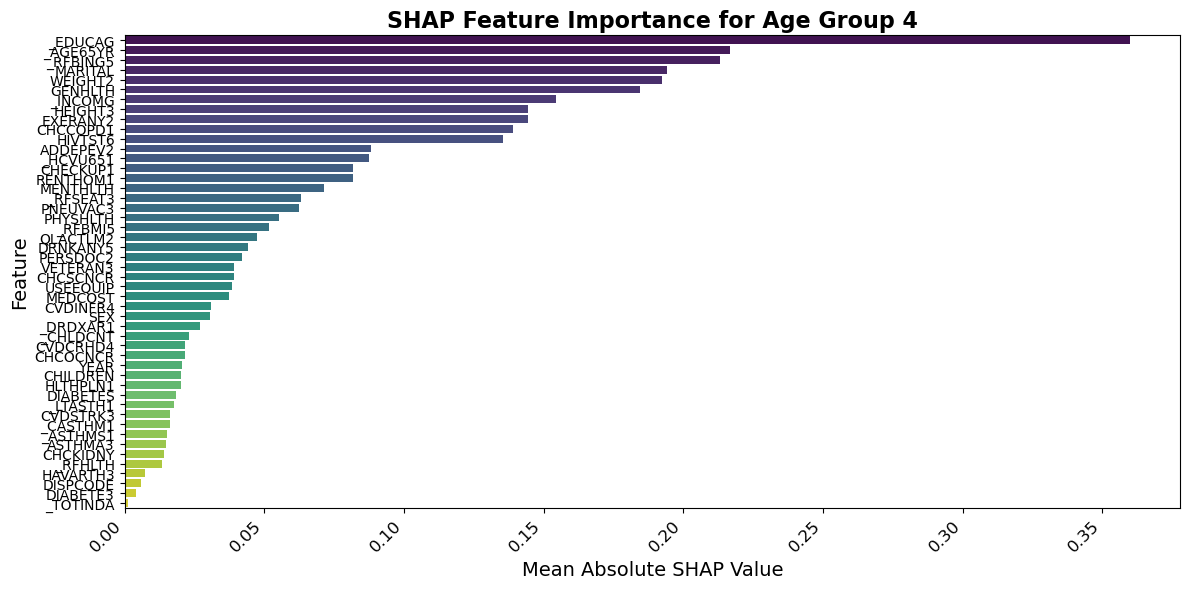

520042


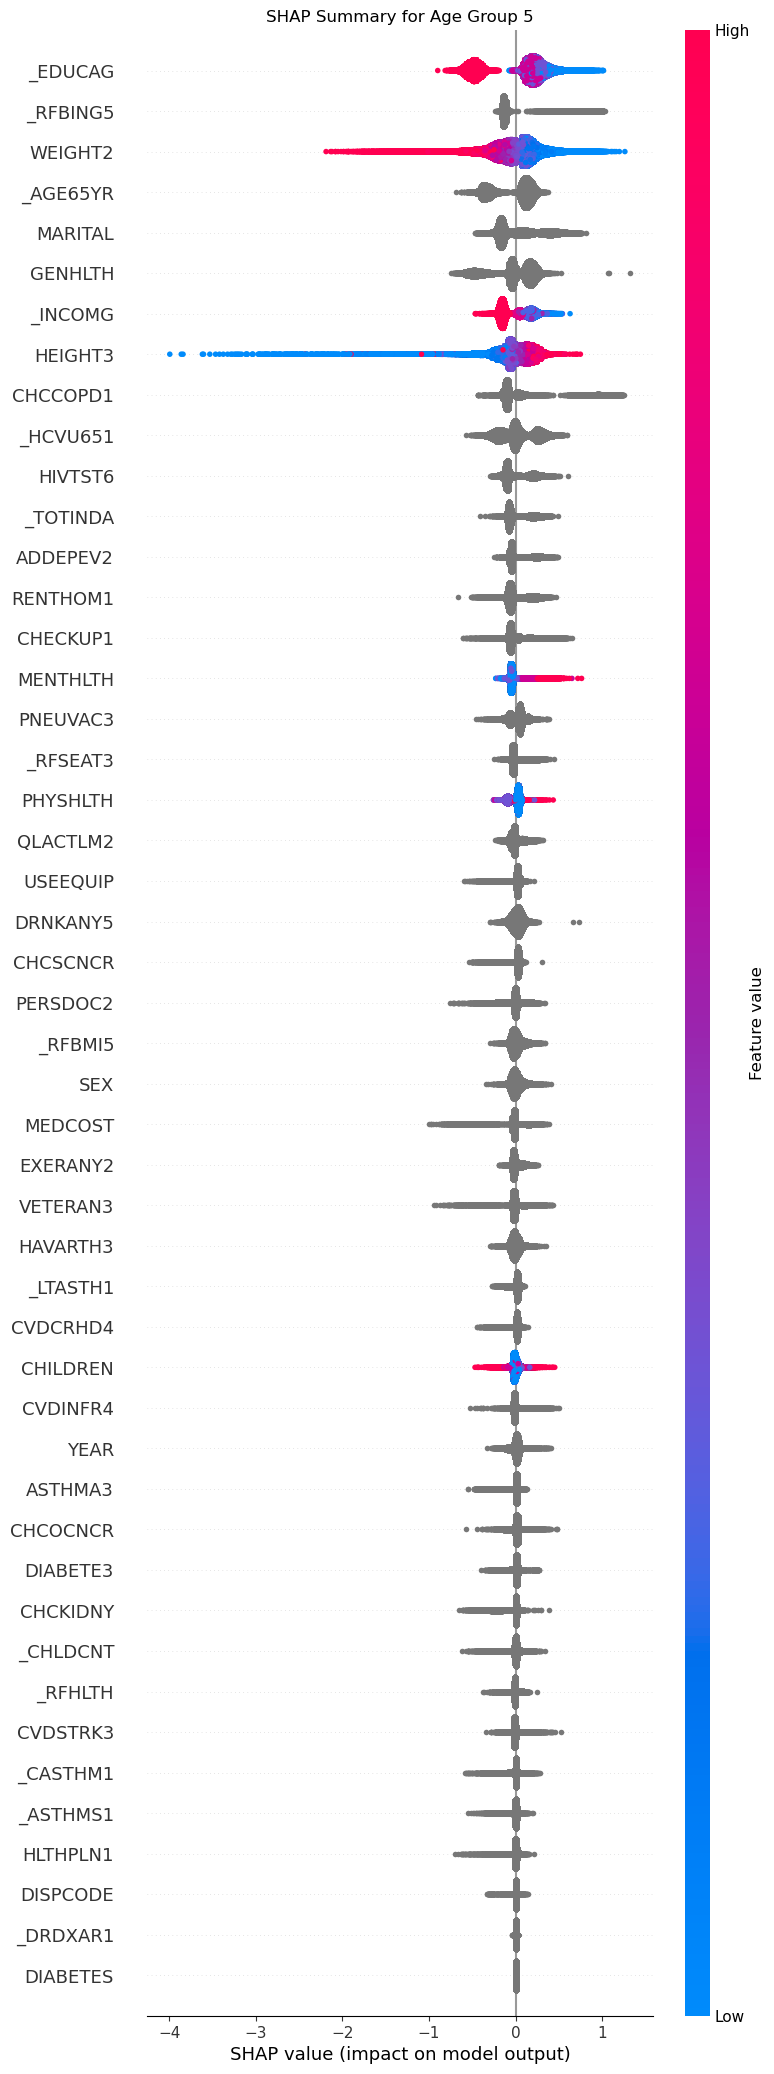

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2096381755.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


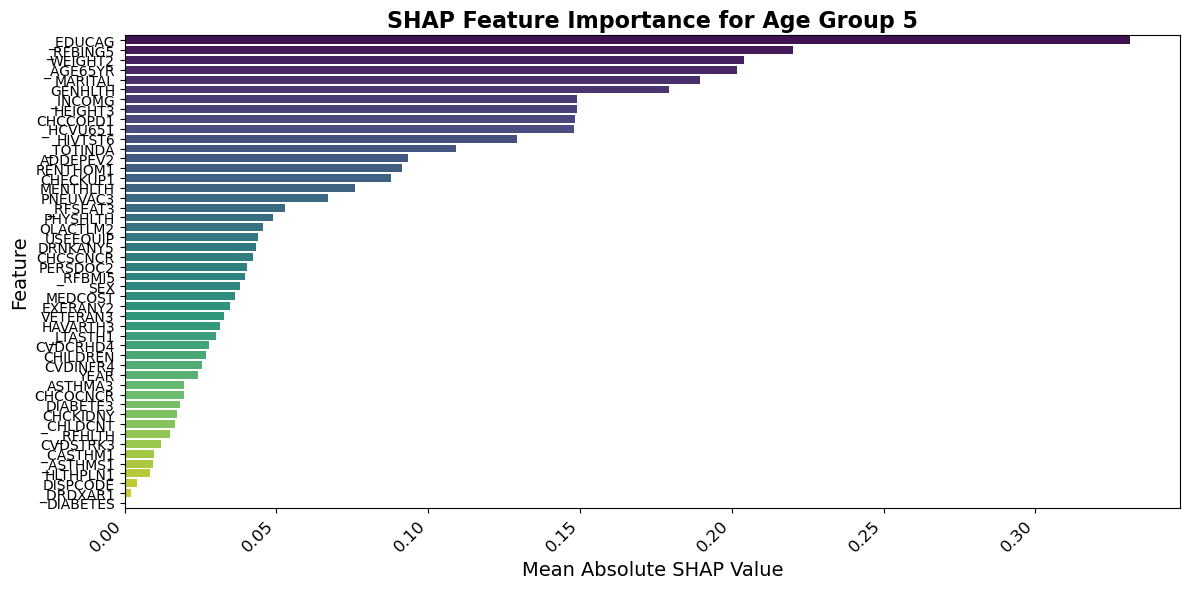

766207


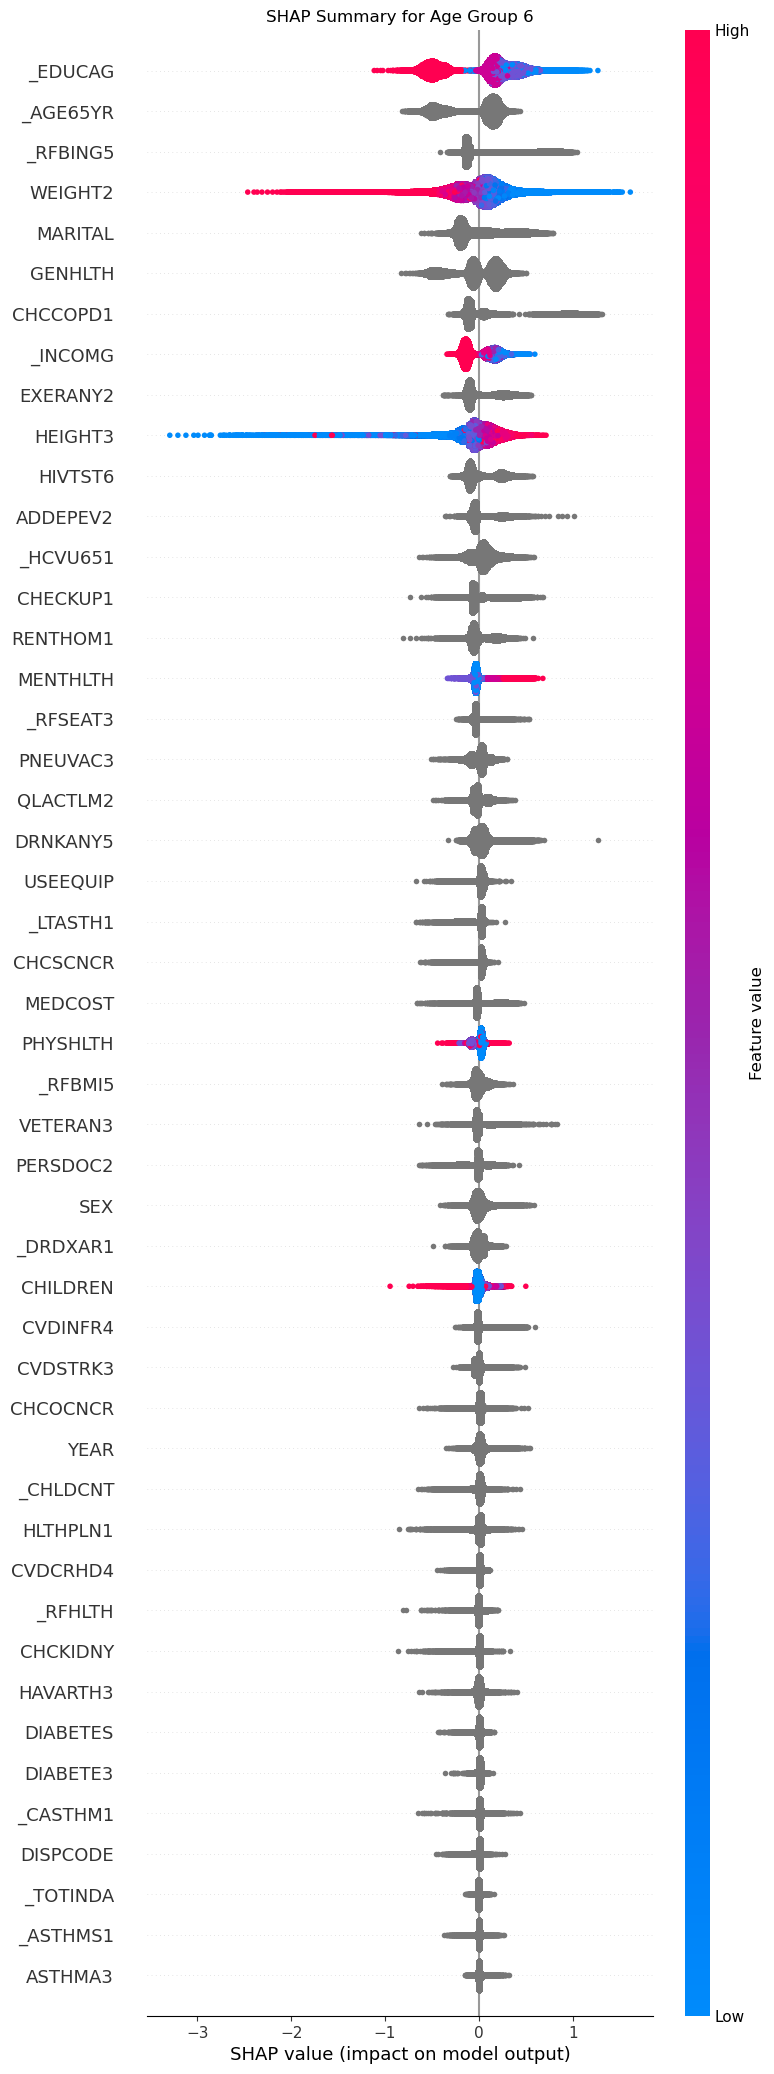

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_1750/2096381755.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


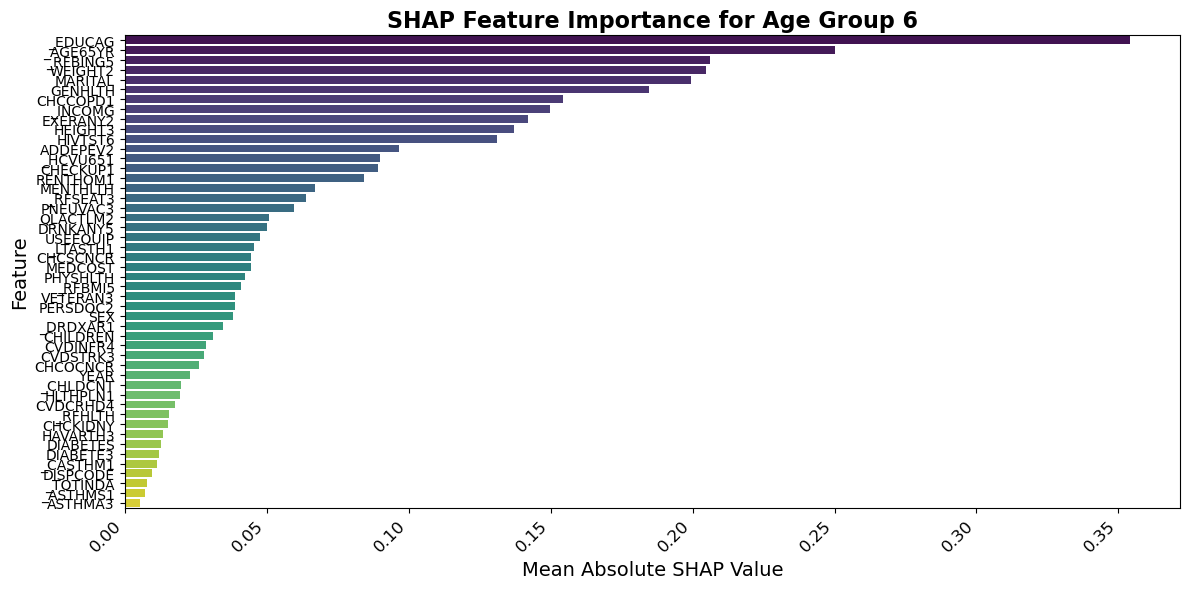

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

from catboost import Pool

# Prepare
age_codes = df_for_report['_AGE_G'].cat.categories if hasattr(df_for_report['_AGE_G'], 'cat') else df_for_report['_AGE_G'].unique()
palette = sns.color_palette("husl", len(age_codes))
bubble_age_list = []

# Features to use (excluding target and _AGE_G)
feature_cols = [col for col in X_combined_with_NaN.columns if col not in ['_RFSMOK3', '_AGE_G']]  # replace 'target' as needed

# Ordinal features → Int64 (nullable integer type)
for col in ordinal_features:
    if col in X_combined_with_NaN.columns:
        X_combined_with_NaN[col] = X_combined_with_NaN[col].astype('Int64')

# Nominal features → string
for col in nominal_features:
    X_combined_with_NaN[col] = (
        X_combined_with_NaN[col].astype(str).replace("nan", "Unknown")
    )


df_for_report = df_for_report.sort_index()
X_combined_with_NaN = X_combined_with_NaN.sort_index()


for idx, age_code in enumerate(age_codes):
    # # Build mask from df_for_report
    # mask = (df_for_report['_AGE_G'] == age_code)

    # # Align mask with X_combined_with_NaN
    # mask_aligned = mask.reindex(X_combined_with_NaN.index, fill_value=False)

    # # Apply safely
    # df_X = X_combined_with_NaN[mask_aligned]


    mask = (df_for_report["_AGE_G"] == age_code).reindex(X_combined_with_NaN.index, fill_value=False)
    df_X = X_combined_with_NaN[mask]
    # Subset data for this age group
    #df_X = X_combined_with_NaN[df_for_report['_AGE_G'] == age_code]
    print(len(df_X))
    X = df_X[feature_cols]
    y = y_combined[mask]
    #y = df_y['_RFSMOK3']  # replace 'target' with your actual target variable

    # Skip if too few samples to train
    if len(df_X) < 10:
        continue

    # Train CatBoost model
    model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
    cat_features=nominal_features)
    # Wrap your data in a Pool
    train_pool = Pool(data=X, label=y, cat_features=nominal_features)
    # Training
    model.fit(train_pool)

    shap_values = model.get_feature_importance(train_pool,type='ShapValues')

    #agregate by HBM constructs by SHAP values
    # The first column is the expected value, so we take the mean absolute SHAP value
    shap_values_no_base = shap_values[:, :-1]
    # Summary plot
    #shap.summary_plot(shap_values_no_base, X_combined_with_NaN, feature_names=X_combined_with_NaN.columns)

    expected_value = shap_values[0, -1]

    shap.summary_plot(
        shap_values_no_base,              # shape = (n_samples, n_features)
        X,              # shape = (n_samples, n_features)
        feature_names=X.columns,
        max_display=len(X.columns),
        show=False  # Prevent immediate display
    )
    plt.title(f"SHAP Summary for Age Group {age_code}")
    plt.show()
    plt.close()

    shap_values_mean = np.abs(shap_values_no_base).mean(axis=0)
    # Create a Series for easier handling

    feature_importance_series = pd.Series(shap_values_mean, index=feature_cols)
    
    #plot the shap values for each age group
    plt.figure(figsize=(12, 6))  # wider figure helps spacing
    shap_values_sorted = feature_importance_series.sort_values(ascending=False)

    sns.barplot(
        x=shap_values_sorted.values, 
        y=shap_values_sorted.index, 
        palette="viridis"
    )

    plt.title(f'SHAP Feature Importance for Age Group {age_code}', fontsize=16, weight='bold')
    plt.xlabel('Mean Absolute SHAP Value', fontsize=14)
    plt.ylabel('Feature', fontsize=14)

    # Fix overlapping x-axis labels
    plt.xticks(rotation=45, ha='right')   # tilt labels
    plt.tick_params(axis='x', labelsize=12)  # bigger, readable ticks

    plt.tight_layout()
    plt.show()
    plt.close()

    #save the model for each age group
    model.save_model(f'../models/part2/catboost_model_age_{age_code}.cbm')


### Age Group Synopses:<br>
**Age Group 1 (Youngest) (18-24):** Education and weight are the strongest predictors, with income showing moderate influence. Height also plays a significant role.<br>
**Age Group 2 (25-34):** Weight becomes the dominant factor, with education and height maintaining strong influence. Income remains moderately important.<br>
**Age Group 3 (35-44):** Similar pattern to Group 2, with weight, education, and height as top predictors. Income continues to show consistent impact.<bR>
**Age Group 4 (45-54):** Weight and height dominate the model predictions, while education and income maintain their significance.<br>
**Age Group 5 (55-64):** Weight, education, and height remain the primary drivers, with income showing steady influence across predictions.<br>
**Age Group 6 (Oldest) (65+):** Weight continues as the strongest predictor, with education and height maintaining importance. Income shows consistent moderate influence.<br>

### Key Financial Barriers for Smokers:
The money-related variables that represent crucial levers and barriers for smokers include:<br>

**INCOME (_INCOMG)** - Appears consistently across all age groups as a moderate to strong predictor, suggesting income level significantly impacts smoking behaviors/cessation success<br>
**Medical Costs (MEDCOST)** - Shows up as a predictor across groups, indicating healthcare affordability affects smoking-related outcomes<br>
**Education (_EDUCAG)** - While not directly money, education strongly correlates with earning potential and appears as a top predictor across all age groups<br>
**Healthcare Coverage (_HCVU651)** - Insurance status appears as a factor, representing financial access to smoking cessation resources<br>

These financial variables suggest that economic barriers—particularly income level, healthcare costs, and insurance coverage—are significant factors in smoking behaviors across all age demographics, with income showing the most consistent influence as a barrier to smoking cessation.RetryClaude can make mistakes. Please double-check responses.